In [32]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict

In [33]:
# define state
class BMIState(TypedDict):
    height_m:float
    weight_kg:float
    bmi:float
    category:str

In [34]:
# define your graph--> remember we need to pass our state into StateGraph Object.
graph=StateGraph(BMIState)

In [ ]:
# function to calculate the bmi this is actually a node
# this will receive the state as input and return state as output
def Calculate_BMI(state:BMIState)->BMIState:
    height=state['height_m']
    weight=state['weight_kg']
    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return state


def labelBMI(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi<18.5:
        state['category']="underweight"
    elif 18.5 <=  bmi <25:
        state['category']  ="Normal"

    elif 25<=bmi <30:
        state['category']="overweight"
    else:
        state['category']="obese"  

    return state      
    

In [36]:
# adding nodes to the graph
graph.add_node("Calculate_BMI",Calculate_BMI)
graph.add_node("label_bmi",labelBMI)

In [37]:
# adding edges to grph
graph.add_edge(START,"Calculate_BMI")
graph.add_edge("Calculate_BMI", "label_bmi")
graph.add_edge("label_bmi",END)

In [38]:
# compile the graph ----> complied variable has become a runnable now
workflow=graph.compile() 

In [39]:
# execute the graph
# pass initial state to the graaph
initial_state={"height_m":1.75,"weight_kg":80}
final_state=workflow.invoke(initial_state)
print(final_state)

{'height_m': 1.75, 'weight_kg': 80, 'bmi': 26.12, 'category': 'overweight'}


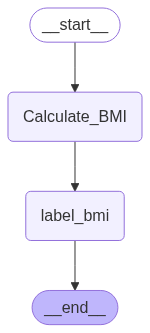

In [40]:
# how to see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())